### **Supervised Machine Learning**


- Supervised Machine Learning is a type of machine learning that learns the relationship between input and output.

- In Supervised Machine Learning, the relationship between the input and labeled output is learnt through the process of training
- Two types of Supervised Machine Learning :
  -  Classification
  -  Regression

- **Classification** is a type of supervised machine learning where the model learns from the data to predict a discrete event or an outcome
    - Logistic Regression, XGBoost Classifier are some of the many machine learning algorithms for a classification problem

- **Regression** is a type of supervised machine learning where the model learns from the data to predict continuous values such as weight.
    - Linear Regression, Gradient Boosted Trees Regression are some of the many machine learning algorithms for a regression problem


*Reference:*


*Géron, Aurélien. "Hands-on machine learning with Scikit-Learn." Keras, and TensorFlow: Concepts, tools, and techniques to build intelligent systems 1 (2019).*


### **Problem Statement**

- The task is a classification problem - Sentiment analytics using Spark NLP

- Kotzias,Dimitrios. (2015). Sentiment Labelled Sentences. UCI Machine Learning Repository. https://doi.org/10.24432/C57604.

- Installing spark-nlp

- https://www.johnsnowlabs.com/mastering-text-classification-with-spark-nlp/



### **Install Dependencies**

In [1]:
# Installing PySpark using pip
!pip install pyspark --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
# Installing spark-nlp
!pip install spark-nlp --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.7/540.7 kB 7.9 MB/s eta 0:00:00


In [3]:
# Installing dependencies
!pip install johnsnowlabs --quiet

In [4]:
# Importing the OS module
import os

# Importing sparknlp
import sparknlp

# Importing dependencies for data preprocessing and modeling
from sparknlp.base import *
from sparknlp.annotator import *

# Importing Pipeline for the classification model
from pyspark.ml import Pipeline

# Importing libraries for data manipulation
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

# Importing metrics from sklearn : confusion matrix, accuracy score,
# confusion_matrix_display for data visualization

from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Importing pandas for data manipulation
import pandas as pd

# Importing Matplotlib and Seaborn for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Please select approrpriate runtime type
# A spark session for Spark NLP is created (or retreived) using sparknlp.start()


spark = sparknlp.start(gpu = True)# for GPU training

print("Spark NLP version", sparknlp.version())

print("Apache Spark version:", spark.version)

spark

Spark NLP version 5.1.4
Apache Spark version: 3.1.2


In [6]:
# Dependencies to import required files from google drive to google - colab environment
from google.colab import drive

In [7]:
# Login
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# Importing the dataset labelled_1.txt, labelled_2.txt, labelled_3.txt
# using spark.read.text()

df_1 = spark.read.text("/content/drive/MyDrive/labelled_1.txt", lineSep = "\n")
df_2 = spark.read.text("/content/drive/MyDrive/labelled_2.txt", lineSep = "\n")
df_3 = spark.read.text("/content/drive/MyDrive/labelled_3.txt", lineSep = "\n")

### **Data Preprocessing**

In [9]:
# Using toDF() function to provide column name "Text"

col_name = ["Text"]
df_a = df_1.toDF(*col_name)
df_b = df_2.toDF(*col_name)
df_c = df_3.toDF(*col_name)

In [10]:
# Display the first five rows of the dataframe df_a

df_b.show(n = 5, truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|Text                                                                                                                                                                                          |
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|A very, very, very slow-moving, aimless movie about a distressed, drifting young man.  	0                                                                                                     |
|Not sure who was more lost - the flat characters or the audience, nearly half of whom walked out.  	0                                                                                         |
|Attempting artiness with black & w

In [11]:
# Split the dataframe string column - text is in one column and the review score is
# in the second column

split_col1 =F.split(df_a['Text'], "\t")
split_col2 = F.split(df_b['Text'], "\t")
split_col3 = F.split(df_c['Text'], "\t")

In [12]:
# Using .withColumn() and getItem() to retrieve each part(text and review score )
# as separate columns

df_u = (
    df_a
    .withColumn('Review',split_col1.getItem(0))
    .withColumn('Score',split_col1.getItem(1))
    .drop('Text')
)

df_u.show(n = 5, truncate  = False)

# 1 - positive sentiment ; 0 - negative sentiment

+----------------------------------------------------------------------------------+-----+
|Review                                                                            |Score|
+----------------------------------------------------------------------------------+-----+
|So there is no way for me to plug it in here in the US unless I go by a converter.|0    |
|Good case, Excellent value.                                                       |1    |
|Great for the jawbone.                                                            |1    |
|Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!   |0    |
|The mic is great.                                                                 |1    |
+----------------------------------------------------------------------------------+-----+
only showing top 5 rows



In [13]:
# # Using .withColumn() and getItem() to retrieve each part(text and review score )
# as separate columns

df_v = (
    df_b
    .withColumn('Review', split_col2.getItem(0))
    .withColumn('Score', split_col2.getItem(1))
    .drop('Text')
)

df_v.show(n = 5, truncate = False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|Review                                                                                                                                                                                      |Score|
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|A very, very, very slow-moving, aimless movie about a distressed, drifting young man.                                                                                                       |0    |
|Not sure who was more lost - the flat characters or the audience, nearly half of whom walked out.                                                                                           |0    |
|Attempting art

In [14]:
# Using .withColumn() and getItem() to retrieve each part(text and review score)
# as separate columns

df_w = (
    df_c
    .withColumn('Review', split_col3.getItem(0))
    .withColumn('Score', split_col3.getItem(1))
    .drop('Text')
)

df_w.show(n = 5, truncate = False)

+---------------------------------------------------------------------------------------+-----+
|Review                                                                                 |Score|
+---------------------------------------------------------------------------------------+-----+
|Wow... Loved this place.                                                               |1    |
|Crust is not good.                                                                     |0    |
|Not tasty and the texture was just nasty.                                              |0    |
|Stopped by during the late May bank holiday off Rick Steve recommendation and loved it.|1    |
|The selection on the menu was great and so were the prices.                            |1    |
+---------------------------------------------------------------------------------------+-----+
only showing top 5 rows



In [15]:
# Combining the dataframe  : using the union()

df = df_u.union(df_v)

In [16]:
# Combining the dataframe  : using the union()

df = df.union(df_w)

In [17]:
# Display the first five rows of the combined dataframe without truncating the
# content

df.show(n = 5, truncate = False)

+----------------------------------------------------------------------------------+-----+
|Review                                                                            |Score|
+----------------------------------------------------------------------------------+-----+
|So there is no way for me to plug it in here in the US unless I go by a converter.|0    |
|Good case, Excellent value.                                                       |1    |
|Great for the jawbone.                                                            |1    |
|Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!   |0    |
|The mic is great.                                                                 |1    |
+----------------------------------------------------------------------------------+-----+
only showing top 5 rows



In [18]:
# Using withColumn() and cast() methods for the Score column  to be converted to
# Double data type()

df = df.withColumn("Score",df.Score.cast(DoubleType()))

In [19]:
# Display the number of rows and columns in the DataFrame

print("Shape of the dataframe:",(df.count(), len(df.columns)))

Shape of the dataframe: (3000, 2)


### **Conversion of Spark DataFrame to a Pandas Dataframe**

In [20]:
# Convert the Spark DataFrame to a Pandas Dataframe using toPandas() method

df_pandas = df.toPandas()

df_pandas['Score'].unique()

array([0., 1.])

In [21]:
# proportion of positive and negative reviews

df_pandas['Score'].value_counts(normalize=True)

0.0    0.5
1.0    0.5
Name: Score, dtype: float64

<Axes: xlabel='Score', ylabel='count'>

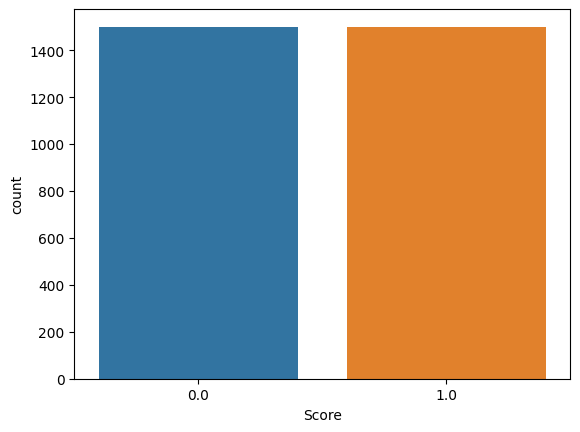

In [22]:
# Visualization of the Score column of the dataframe using Seaborn count plot

sns.countplot(data = df_pandas, x = "Score")

### **Quiz**

1) Display the first five rows of the df_pandas dataframe

2) Create a dataframe df_1 corresponding to a score (label) of 1

3) Generate a word cloud for the text in the df_1 dataframe



1) Display the first five rows of the df_pandas dataframe

In [23]:
df_pandas.head()

,Review,Score
0,So there is no way for me to plug it in here i...,0.0
1,"Good case, Excellent value.",1.0
2,Great for the jawbone.,1.0
3,Tied to charger for conversations lasting more...,0.0
4,The mic is great.,1.0


2) Save the reviews corresponding to a score of 1 in a dataframe df_1

In [24]:
df_1 = df_pandas[df_pandas['Score'] == 1]

3) Generate a word cloud for the text in the df_1 dataframe

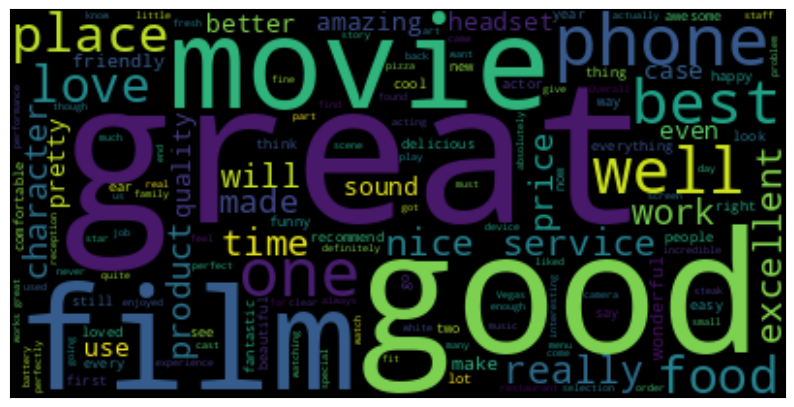

In [25]:
# !pip install wordcloud
from wordcloud import WordCloud, STOPWORDS # Stopwords - data cleaning
import matplotlib.pyplot as plt
stopwords = set(STOPWORDS)
wordcloud2 = WordCloud(stopwords = stopwords, background_color = "black").generate(' '.join(df_1['Review']))
plt.figure(figsize = (10, 15))
plt.tick_params(left = False, labelleft = False ,
                labelbottom = False, bottom = False)
plt.imshow(wordcloud2, interpolation = "bilinear")
plt.show()

### **Data processing and Initializing the pipeline for Classification model**

- Document Assembler is the entry point for the Spark NLP pipeline
- Document Assembler prepares the data in a way, it can be processed by Spark NLP

In [46]:
# Initializing document_assembler with Review  as thecolumn
# and output column set to "document"

document_assembler = DocumentAssembler() \
          .setInputCol("Review") \
          .setOutputCol("document")


- Tokenizer is imported from sparknlp.annotator library
- Tokenizes the input raw text in document type column to a tokenized sentence.

In [47]:
# Initialize the tokenizer with the input column set to "document" and output column
# set to "token"
tokenizer = Tokenizer() \
          .setInputCols("document") \
          .setOutputCol("token")

### **Embeddings**


- In NLP, embedding is a real-valued vector representation of a word, encoded in such a way that words closer in vector space are similar in meaning

- BERT - Bidirectional encoded representations from transfromers : provides dense vector representations for text, BERT model uses deep, pretrained neural network architecture based on transformers

https://sparknlp.org/api/python/reference/autosummary/sparknlp/annotator/embeddings/bert_embeddings/index.html

In [28]:
# Initializing token level embeddings from  bert : with the bert_base_uncased model
# input columns set to "document", "token"
# output columns set to "embeddings"
bert_embeddings = BertEmbeddings().pretrained(name = "bert_base_uncased", lang = "en") \
                  .setInputCols(["document", "token"]) \
                  .setOutputCol("embeddings")

bert_base_uncased download started this may take some time.
Approximate size to download 392.5 MB
[OK!]


- Sentence embeddings encode sentences to fixed length vectors to capture the semantic meaning of sentences

In [48]:
# Initializing sentence embeddings with "document" and "embeddings" as input column
# "sentence_embeddings" as output column
# "AVERAGE" pooling strategy

embeddings_sentence = SentenceEmbeddings() \
                      .setInputCols(["document", "embeddings"]) \
                      .setOutputCol("sentence_embeddings") \
                      .setPoolingStrategy("AVERAGE")

ClassifierDLApproach() uses a deep neural network for text classification problem

In [49]:
# Initialize ClassifierDLApproach - for text classification
# The model uses "sentence_embeddings" as the input column
# "class" as the output column, "Score" as the label- column
# Hyperparameters : Epochs, Learning rate and Batch Size

classifierdl = ClassifierDLApproach() \
              .setInputCols(["sentence_embeddings"]) \
              .setOutputCol("class") \
              .setLabelColumn("Score") \
              .setMaxEpochs(10) \
              .setLr(0.001) \
              .setBatchSize(8) \
              .setEnableOutputLogs(True)

In [50]:
# Initializing the pipeline with document_assembler, tokenizer, bert_embeddings,
# sentence_embeddings and ClassifierDL stages
bert_clf_pipeline  = Pipeline(stages=[document_assembler,
                                      tokenizer,
                                      bert_embeddings,
                                      embeddings_sentence,
                                      classifierdl])

In [51]:
# Split the dataset into train and test datasets : 80% for the training dataset
# 20% for the test dataset

(train, test) = df.randomSplit([0.8, 0.2], 42)

In [52]:
# Model training with bert_clf_pipeline.fit() method
clf_pipelineModel = bert_clf_pipeline.fit(train)

In [53]:
# Predictions from the model with .transform() method
predictions = clf_pipelineModel.transform(test)
predictions.columns

['Review',
 'Score',
 'document',
 'token',
 'embeddings',
 'sentence_embeddings',
 'class']

### **Classification Model - performance**

In [61]:
# Converting the predictions dataframe to Pandas
df_metric = predictions.select('Review','Score', 'class.result').toPandas()

In [68]:
# Extracting the predicted label from class.result
df_metric['result'] = df_metric['result'].apply(lambda x: x[0])

In [69]:
# Convert predicted label to float64 datatype
df_metric['result'] = df_metric['result'].astype('float64')

In [70]:
# Computation of the confusion matrix
cm = confusion_matrix(df_metric['Score'], df_metric['result'])

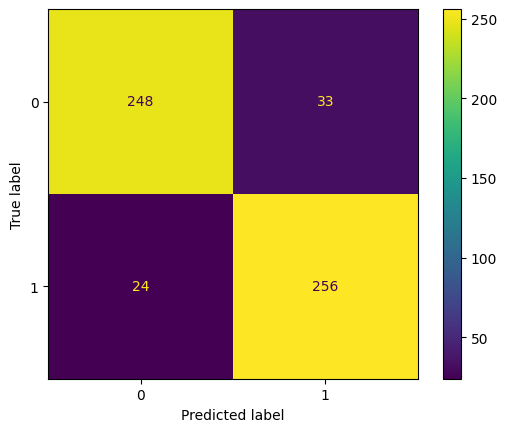

In [71]:
# Visualization of the Confusion Matrix

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [72]:
accuracy = format(accuracy_score(df_metric['Score'], df_metric['result']), ".2f")
accuracy

'0.90'